# Iterative scipy minimize fitting tutorial: broadband non-MBI filters

This notebook is a tutorial version of the broadband single-filter scipy-minimize notebooks. It covers the non-MBI/IPOL filters from the 2023-09-14 processed table:

- `625-50`
- `675-50`
- `725-50`
- `750-50`
- `775-50`

These are the broadband 625, 675, 725, 750, and 775 nm filters in the processed CSV naming convention. This tutorial also fits an IMR offset angle as `image_rotator.delta_theta`, following the existing `with_IMR_offset` notebooks. The fitting mechanics are the same as the parent notebooks: load data, load a previous fit as `p0`, build a system Mueller matrix, minimize, update `p0`, and iterate until the likelihood change is small.

In [1]:
import sys
import os
from pathlib import Path

# Add the repository root containing instruments.py to the Python path.
custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
sys.path.append(custom_module_path)

import instruments as inst
import numpy as np
import pandas as pd
import json

## Input CSV format for broadband fitting

For broadband/IPOL filters, call `inst.read_csv` with `obs_mode="IPOL"` and `obs_filter` set to the `FILTER01` value, such as `625-50` or `775-50`.

Required columns:

| column | meaning |
| --- | --- |
| `OBS-MOD` | Observation mode. These rows are usually `IPOL`. |
| `FILTER01` | Filter name, for example `625-50` or `775-50`. |
| `RET-POS1` | HWP angle for that exposure, in degrees. |
| `D_IMRANG` | Image rotator angle, in degrees. |
| `U_FLC` | FLC state label. `A` maps to `flc_a_theta`; `B` maps to `flc_b_theta`. |
| `diff`, `sum` | Scalar single-difference and single-sum measured values. |
| `diff_std`, `sum_std` | Scalar uncertainties for `diff` and `sum`. |

`read_csv` returns interleaved values `[diff0, sum0, diff1, sum1, ...]`, matching interleaved uncertainties, and one configuration dictionary per row.

In [2]:
broadband_file_path = os.path.join(custom_module_path, "data", "20230914_processed_table.csv")

initial_fits_directory = os.path.join(
    custom_module_path,
    "scipy_minimize",
    "data_files",
    "initial",
)
produced_fits_directory = os.path.join(
    custom_module_path,
    "scipy_minimize",
    "data_files",
    "produced",
)

# Tutorial outputs go into their own directory so running this notebook does not overwrite
# the existing fit products used by other notebooks.
save_fits_directory = os.path.join(
    produced_fits_directory,
    "tutorials",
    "broadband_iterative_scipy_minimize",
)
os.makedirs(save_fits_directory, exist_ok=True)

fit_jobs = [
    {
        "label": "625-50",
        "wavelength": "625-50",
        "obs_mode": "IPOL",
        "obs_filter": "625-50",
        "file_path": broadband_file_path,
        "previous_fit": os.path.join(initial_fits_directory, "625-50nm.txt"),
        "em_gain": 1.139634,
        "output_prefix": "625-50nm_no_IMR_offset_or_IMR_and_HWP_constraints_tutorial",
        "flc_a_theta": 0,
        "flc_b_theta": 45,
    },
    {
        "label": "675-50",
        "wavelength": "675-50",
        "obs_mode": "IPOL",
        "obs_filter": "675-50",
        "file_path": broadband_file_path,
        "previous_fit": os.path.join(initial_fits_directory, "675-50nm.txt"),
        "em_gain": 1.177732,
        "output_prefix": "675-50nm_no_IMR_offset_or_IMR_and_HWP_constraints_tutorial",
        "flc_a_theta": 0,
        "flc_b_theta": 45,
    },
    {
        "label": "725-50",
        "wavelength": "725-50",
        "obs_mode": "IPOL",
        "obs_filter": "725-50",
        "file_path": broadband_file_path,
        "previous_fit": os.path.join(initial_fits_directory, "725-50nm.txt"),
        "em_gain": 1.184177,
        "output_prefix": "725-50nm_no_IMR_offset_or_IMR_and_HWP_constraints_tutorial",
        "flc_a_theta": 0,
        "flc_b_theta": 45,
    },
    {
        "label": "750-50",
        "wavelength": "750-50",
        "obs_mode": "IPOL",
        "obs_filter": "750-50",
        "file_path": broadband_file_path,
        "previous_fit": os.path.join(initial_fits_directory, "750-50nm.txt"),
        "em_gain": 1.180120,
        "output_prefix": "750-50nm_no_IMR_offset_or_IMR_and_HWP_constraints_tutorial",
        "flc_a_theta": 0,
        "flc_b_theta": 45,
    },
    {
        "label": "775-50",
        "wavelength": "775-50",
        "obs_mode": "IPOL",
        "obs_filter": "775-50",
        "file_path": broadband_file_path,
        "previous_fit": os.path.join(initial_fits_directory, "775-50nm.txt"),
        "em_gain": 1.190700,
        "output_prefix": "775-50nm_no_IMR_offset_or_IMR_and_HWP_constraints_tutorial",
        "flc_a_theta": 0,
        "flc_b_theta": 45,
    },
]

pd.DataFrame(fit_jobs)[["label", "obs_mode", "obs_filter", "em_gain", "previous_fit", "output_prefix"]]

,label,obs_mode,obs_filter,em_gain,previous_fit,output_prefix
0,625-50,IPOL,625-50,1.139634,/home/rebeccaz/Github/vampires_calibration/sci...,625-50nm_no_IMR_offset_or_IMR_and_HWP_constrai...
1,675-50,IPOL,675-50,1.177732,/home/rebeccaz/Github/vampires_calibration/sci...,675-50nm_no_IMR_offset_or_IMR_and_HWP_constrai...
2,725-50,IPOL,725-50,1.184177,/home/rebeccaz/Github/vampires_calibration/sci...,725-50nm_no_IMR_offset_or_IMR_and_HWP_constrai...
3,750-50,IPOL,750-50,1.180120,/home/rebeccaz/Github/vampires_calibration/sci...,750-50nm_no_IMR_offset_or_IMR_and_HWP_constrai...
4,775-50,IPOL,775-50,1.190700,/home/rebeccaz/Github/vampires_calibration/sci...,775-50nm_no_IMR_offset_or_IMR_and_HWP_constrai...


## Quick sanity check: raw rows and parsed arrays

These previews help catch the two most common setup mistakes: using the wrong `FILTER01` label and missing scalar uncertainty columns.

In [3]:
broadband_raw = pd.read_csv(broadband_file_path)
broadband_columns = ["OBS-MOD", "FILTER01", "RET-POS1", "D_IMRANG", "U_FLC", "diff", "diff_std", "sum", "sum_std"]

print("Available broadband rows by FILTER01:")
print(broadband_raw[broadband_raw["OBS-MOD"].eq("IPOL")]["FILTER01"].value_counts().sort_index())

print("\nBroadband/IPOL example rows:")
print(
    broadband_raw[broadband_raw["FILTER01"].eq("625-50")][broadband_columns]
    .head(6)
    .to_string(index=False)
)

sample_job = fit_jobs[0]
interleaved_values, interleaved_stds, configuration_list = inst.read_csv(
    sample_job["file_path"],
    obs_mode=sample_job["obs_mode"],
    obs_filter=sample_job["obs_filter"],
    flc_a_theta=sample_job["flc_a_theta"],
    flc_b_theta=sample_job["flc_b_theta"],
)

print(f"\nParsed sample job: {sample_job['label']}")
print(f"interleaved_values shape: {np.shape(interleaved_values)}")
print(f"interleaved_stds shape: {np.shape(interleaved_stds)}")
print(f"configuration_list length: {len(configuration_list)}")
print("First three parsed configurations:")
for config in configuration_list[:3]:
    print(config)

Available broadband rows by FILTER01:
FILTER01
625-50    160
675-50    160
725-50    160
750-50    160
775-50    160
Open      160
Name: count, dtype: int64

Broadband/IPOL example rows:
OBS-MOD FILTER01  RET-POS1  D_IMRANG U_FLC    diff  diff_std    sum   sum_std
   IPOL   625-50       0.0      45.0     A -1080.0  66.22258 1763.5  81.24302
   IPOL   625-50       0.0      45.0     B   636.0 128.18863 1712.0   79.7065
   IPOL   625-50       0.0      57.5     A -1081.0  66.52477 1759.0 82.804184
   IPOL   625-50       0.0      57.5     B   758.0   65.0891 1706.0  80.72938
   IPOL   625-50       0.0      70.0     A -1312.0  71.02066 1774.0 356.43402
   IPOL   625-50       0.0      70.0     B  1125.0  66.99792 1711.0 80.296646

Parsed sample job: 625-50
interleaved_values shape: (320,)
interleaved_stds shape: (320,)
configuration_list length: 160
First three parsed configurations:
{'hwp': {'theta': 0.0}, 'image_rotator': {'theta': 45.0}, 'flc': {'theta': 0}}
{'hwp': {'theta': 0.0}, 'image_

## Starting-fit JSON format

The broadband jobs use the files in `scipy_minimize/data_files/initial/` as starting points.

The JSON format is:

- outer keys are optical components (`dichroic`, `flc`, `optics`, `image_rotator`, `hwp`, and `lp`),
- inner keys are fit parameters,
- `phi` values are in radians,
- `theta` and `delta_theta` values are in degrees,
- `epsilon` values are unitless,
- old starting-fit files may not contain `image_rotator.delta_theta`; this tutorial initializes that IMR offset to `0.0` degrees before fitting.

The order of entries in `p0` matters because `inst.parse_configuration(p0)` turns this dictionary into the vector passed to scipy. Keep `bounds` in the same order.

In [4]:
for sample_job in (fit_jobs[0], fit_jobs[-1]):
    print("\n" + sample_job["label"])
    print(sample_job["previous_fit"])
    with open(sample_job["previous_fit"], "r") as f:
        sample_p0 = json.load(f)
    print(json.dumps(sample_p0, indent=4))


625-50
/home/rebeccaz/Github/vampires_calibration/scipy_minimize/data_files/initial/625-50nm.txt
{
    "dichroic": {
        "phi": 0.30872304463963207,
        "epsilon": 0.010945621474919988,
        "theta": 1.8315213575483158
    },
    "flc": {
        "phi": 3.318462559843585,
        "delta_theta": 1.798029718547543
    },
    "optics": {
        "phi": -0.8083964583195624,
        "epsilon": 0.013895280106864007,
        "theta": 18.01712022177098
    },
    "image_rotator": {
        "phi": 1.365065666004961
    },
    "hwp": {
        "phi": 2.752521179595714,
        "delta_theta": -1.9748257333612886
    },
    "lp": {
        "theta": -0.15074376412465285
    }
}

775-50
/home/rebeccaz/Github/vampires_calibration/scipy_minimize/data_files/initial/775-50nm.txt
{
    "dichroic": {
        "phi": -0.4453209230456945,
        "epsilon": 0.22985493763100695,
        "theta": 19.817421224767727
    },
    "flc": {
        "phi": 3.530192368576989,
        "delta_theta": 4.99759

## Bounds

These broadband jobs use the broad bounds from `fixed_EM_gain_no_retardance_restrictions/all_wavelengths_no_IMR_offset_or_IMR_and_HWP_retardance_constraints.ipynb`, with the IMR offset-angle bound added from the existing `with_IMR_offset` notebooks.

In [5]:
def broadband_bounds():
    return [
        (0, 2 * np.pi),  # dichroic phi
        (0, 1),  # dichroic epsilon
        (-90, 90),  # dichroic theta
        (0.4 * 2 * np.pi, 0.6 * 2 * np.pi),  # FLC phi
        (-5, 5),  # FLC delta_theta
        (0, 2 * np.pi),  # optics phi
        (0, 1),  # optics epsilon
        (-90, 90),  # optics theta
        (0, 2 * np.pi),  # image rotator phi
        (-1, 1),  # image rotator delta_theta / IMR offset angle
        (0, 2 * np.pi),  # HWP phi
        (-5, 5),  # HWP delta_theta
        (-5, 5),  # LP theta
    ]

## Fit each broadband filter iteratively

This is the same iterative structure as the parent notebooks, generalized over `fit_jobs` so the five broadband filters can live in one tutorial. Outputs are written to the tutorial output directory defined above.


Fitting 625-50 (IPOL)
Initial logl value: 6051.520932212983


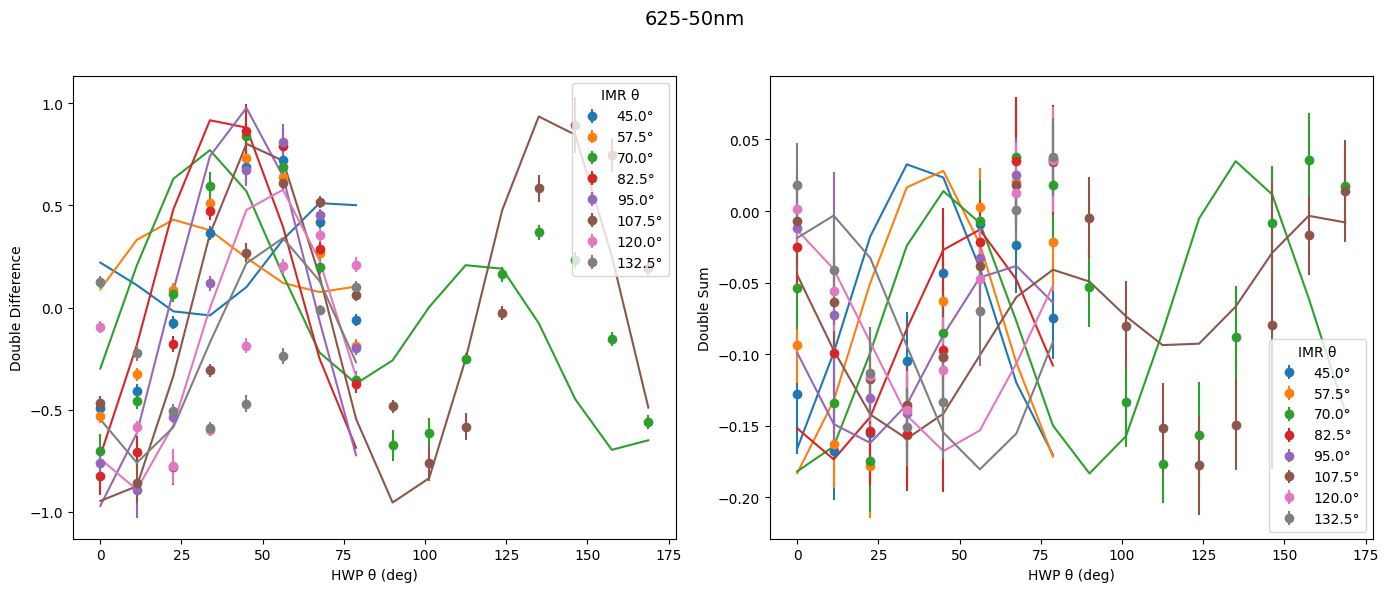

Before p0: {'dichroic': {'phi': 0.30872304463963207, 'epsilon': 0.010945621474919988, 'theta': 1.8315213575483158}, 'flc': {'phi': 3.318462559843585, 'delta_theta': 1.798029718547543}, 'optics': {'phi': 0.8083964583195624, 'epsilon': 0.013895280106864007, 'theta': 18.01712022177098}, 'image_rotator': {'phi': 1.365065666004961, 'delta_theta': 0.0}, 'hwp': {'phi': 2.752521179595714, 'delta_theta': -1.9748257333612886}, 'lp': {'theta': -0.15074376412465285}}


KeyboardInterrupt: 

In [6]:
convergence_fraction = 0.001
max_iterations = 50

for job in fit_jobs:
    wavelength = job["wavelength"]
    print("\n" + "=" * 80)
    print(f"Fitting {job['label']} ({job['obs_mode']})")

    interleaved_values, interleaved_stds, configuration_list = inst.read_csv(
        job["file_path"],
        obs_mode=job["obs_mode"],
        obs_filter=job["obs_filter"],
        flc_a_theta=job["flc_a_theta"],
        flc_b_theta=job["flc_b_theta"],
    )

    with open(job["previous_fit"], "r") as f:
        past_fit = json.load(f)
    past_fit.setdefault("image_rotator", {})
    past_fit["image_rotator"].setdefault("delta_theta", 0.0)

    theta_pol = past_fit["lp"]["theta"]
    delta_HWP = past_fit["hwp"]["phi"]
    offset_HWP = past_fit["hwp"]["delta_theta"]
    delta_derot = past_fit["image_rotator"]["phi"]
    offset_derot = past_fit["image_rotator"]["delta_theta"]
    delta_opts = past_fit["optics"]["phi"]
    epsilon_opts = past_fit["optics"]["epsilon"]
    rot_opts = past_fit["optics"]["theta"]
    delta_dichroic = past_fit["dichroic"]["phi"]
    epsilon_dichroic = past_fit["dichroic"]["epsilon"]
    rot_dichroic = past_fit["dichroic"]["theta"]
    delta_FLC = past_fit["flc"]["phi"]
    rot_FLC = past_fit["flc"]["delta_theta"]
    em_gain = job["em_gain"]

    # NOTE: Components must be listed downstream to upstream.
    system_dict = {
        "components": {
            "wollaston": {
                "type": "wollaston_prism_function",
                "properties": {"beam": "o", "transmission_ratio": em_gain},
            },
            "dichroic": {
                "type": "diattenuator_retarder_function",
                "properties": {
                    "phi": delta_dichroic,
                    "epsilon": epsilon_dichroic,
                    "theta": rot_dichroic,
                },
            },
            "flc": {
                "type": "general_retarder_function",
                "properties": {"phi": delta_FLC, "theta": 0, "delta_theta": rot_FLC},
            },
            "optics": {
                "type": "diattenuator_retarder_function",
                "properties": {
                    "phi": delta_opts,
                    "epsilon": epsilon_opts,
                    "theta": rot_opts,
                },
            },
            "image_rotator": {
                "type": "general_retarder_function",
                "properties": {"phi": delta_derot, "theta": 0, "delta_theta": offset_derot},
            },
            "hwp": {
                "type": "general_retarder_function",
                "properties": {"phi": delta_HWP, "theta": 0, "delta_theta": offset_HWP},
            },
            "lp": {
                "type": "general_linear_polarizer_function_with_theta",
                "properties": {"theta": theta_pol},
            },
        }
    }

    bounds = broadband_bounds()
    system_mm = inst.generate_system_mueller_matrix(system_dict)

    p0 = {
        "dichroic": {
            "phi": np.abs(delta_dichroic),
            "epsilon": epsilon_dichroic,
            "theta": rot_dichroic,
        },
        "flc": {"phi": delta_FLC, "delta_theta": rot_FLC},
        "optics": {
            "phi": np.abs(delta_opts),
            "epsilon": epsilon_opts,
            "theta": rot_opts,
        },
        "image_rotator": {"phi": delta_derot, "delta_theta": offset_derot},
        "hwp": {"phi": delta_HWP, "delta_theta": offset_HWP},
        "lp": {"theta": theta_pol},
    }

    p0_values, p0_keywords = inst.parse_configuration(p0)
    s_in = np.array([1, 0, 0, 0])

    logl_value = inst.logl(
        p0_values,
        p0_keywords,
        system_mm,
        interleaved_values,
        interleaved_stds,
        configuration_list,
        s_in=s_in,
        logl_function=None,
        process_dataset=inst.process_dataset,
        process_errors=inst.process_errors,
        process_model=inst.process_model,
    )
    print("Initial logl value:", logl_value)

    model = inst.model(
        p0_values,
        p0_keywords,
        system_mm,
        configuration_list,
        process_model=inst.process_model,
    )
    inst.plot_data_and_model(interleaved_values, interleaved_stds, model, configuration_list, wavelength=wavelength)

    iteration = 1
    previous_logl_value = 1000000
    new_logl_value = 0

    while (
        abs(previous_logl_value - new_logl_value)
        > convergence_fraction * abs(previous_logl_value)
        and iteration <= max_iterations
    ):
        print("Before p0:", p0)
        if iteration > 1:
            previous_logl_value = new_logl_value

        result, new_logl_value = inst.minimize_system_mueller_matrix(
            p0,
            system_mm,
            interleaved_values,
            interleaved_stds,
            configuration_list,
            s_in=s_in,
            process_dataset=inst.process_dataset,
            process_errors=inst.process_errors,
            process_model=inst.process_model,
            bounds=bounds,
        )

        print("Iteration #:", iteration)
        print("logl_value:", new_logl_value)
        print("Best Fit Parameters:", result.x)

        updated_system_mm = inst.update_system_mm(result.x, p0_keywords, system_mm)
        model = inst.model(
            result.x,
            p0_keywords,
            updated_system_mm,
            configuration_list,
            process_model=inst.process_model,
        )

        save_path = os.path.join(save_fits_directory, f"{job['output_prefix']}.png")
        inst.plot_data_and_model(
            interleaved_values,
            interleaved_stds,
            model,
            configuration_list,
            wavelength=wavelength,
            save_path=save_path,
        )

        inst.update_p0(p0, result.x)
        print("After p0:", p0)

        output_filename = os.path.join(save_fits_directory, f"{job['output_prefix']}.txt")
        with open(output_filename, "w") as f:
            json.dump(p0, f, indent=4)

        iteration += 1

    if iteration > max_iterations:
        print(f"Stopped after max_iterations={max_iterations}; inspect the last saved fit before using it.")

## Summary table

In [ ]:
def radians_to_waves(rad):
    return rad / (2 * np.pi)


summary_rows = []
param_names = [
    "label",
    "obs_mode",
    "dichroic_phi (waves)",
    "dichroic_epsilon",
    "dichroic_theta",
    "flc_phi (waves)",
    "flc_delta_theta",
    "optics_phi (waves)",
    "optics_epsilon",
    "optics_theta",
    "image_rotator_phi (waves)",
    "image_rotator_delta_theta",
    "hwp_phi (waves)",
    "hwp_delta_theta",
    "lp_theta",
]

for job in fit_jobs:
    filename = os.path.join(save_fits_directory, f"{job['output_prefix']}.txt")
    try:
        with open(filename, "r") as f:
            p0 = json.load(f)
        summary_rows.append(
            {
                "label": job["label"],
                "obs_mode": job["obs_mode"],
                "dichroic_phi (waves)": radians_to_waves(p0["dichroic"]["phi"]),
                "dichroic_epsilon": p0["dichroic"]["epsilon"],
                "dichroic_theta": p0["dichroic"]["theta"],
                "flc_phi (waves)": radians_to_waves(p0["flc"]["phi"]),
                "flc_delta_theta": p0["flc"]["delta_theta"],
                "optics_phi (waves)": radians_to_waves(p0["optics"]["phi"]),
                "optics_epsilon": p0["optics"]["epsilon"],
                "optics_theta": p0["optics"]["theta"],
                "image_rotator_phi (waves)": radians_to_waves(p0["image_rotator"]["phi"]),
                "image_rotator_delta_theta": p0["image_rotator"].get("delta_theta", np.nan),
                "hwp_phi (waves)": radians_to_waves(p0["hwp"]["phi"]),
                "hwp_delta_theta": p0["hwp"]["delta_theta"],
                "lp_theta": p0["lp"]["theta"],
            }
        )
    except Exception as exc:
        print(f"Could not load {filename}: {exc}")

df = pd.DataFrame(summary_rows, columns=param_names)
print("\nSummary of final p0 values for each broadband fit (retardances in waves):")
print(df.to_string(index=False))